# Import a voxelized pig geometry and visualize its magnetization

This example replaces the old Mathematica `Image3D` workflow and the custom `TestGeometry-P.I.G.go` executable. PyVista voxelizes a CC0 triangular pig model, OVFToolkit exports the scalar mask, and MuMax3's `ext_InitGeomFromOVF` initializes the mesh and geometry from the OVF file.

After relaxation, the pig surface encodes magnetization in HSV:

- **Hue** is the direction of the tangential component in a local surface basis.
- **Saturation** is the tangential-component magnitude.
- **Brightness** is $(m\cdot n+1)/2$: inward-normal magnetization is black and outward-normal magnetization is fully bright.

A small number of seeded 3D streamlines show the exported demagnetizing field and are colored independently by $|B_\mathrm{demag}|$.


## Set up a disposable workspace and PyVista

The checked-in **Origins of the Pig** body mesh is by Keenan Crane and is dedicated to the public domain under CC0 1.0. See `model/README.md` for provenance.


In [1]:
%pip install -q ipynbname matplotlib pyvista

import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import ipynbname
import matplotlib.pyplot as plt
import numpy as np
import ovftoolkit as ovf

if "work_dir" in globals():
    shutil.rmtree(work_dir, ignore_errors=True)

try:
    notebook_directory = ipynbname.path().parent
except (FileNotFoundError, IndexError):
    # Headless executors such as nbconvert cannot query a notebook server.
    notebook_directory = Path(
        os.environ.get("OVFTOOLKIT_NOTEBOOK_DIR", Path.cwd())
    ).resolve()
work_dir = Path(tempfile.mkdtemp(prefix="ovftoolkit-imported-geometry-"))

configured_mumax = os.environ.get("MUMAX3")
mumax3 = Path(configured_mumax or shutil.which("mumax3") or "")
if not mumax3.is_file():
    raise RuntimeError("mumax3 was not found; put it on PATH or set MUMAX3")
mumax3 = mumax3.resolve()
print(f"Temporary workspace: {work_dir}")
print(f"MuMax3: {mumax3}")
import matplotlib.colors as colors
import pyvista as pv

pv.set_jupyter_backend("static")
model_file = notebook_directory / "model" / "origins-of-the-pig.obj"
template = notebook_directory / "pig.mx3.in"

Note: you may need to restart the kernel to use updated packages.
Temporary workspace: C:\Users\Artej\AppData\Local\Temp\ovftoolkit-imported-geometry-j73v4jkq
MuMax3: C:\Users\Artej\go\bin\mumax3.exe


## Orient, scale, and voxelize the open model

The OBJ's original longest axis becomes simulation `x`, its original width becomes `y`, and its vertical direction becomes `z`. Set the mesh dimensions, isotropic cell size, and fraction of the box's `x` length occupied by the pig below. The model remains centered and keeps its original aspect ratio; the derived clearance from each pair of box faces is reported before voxelization.


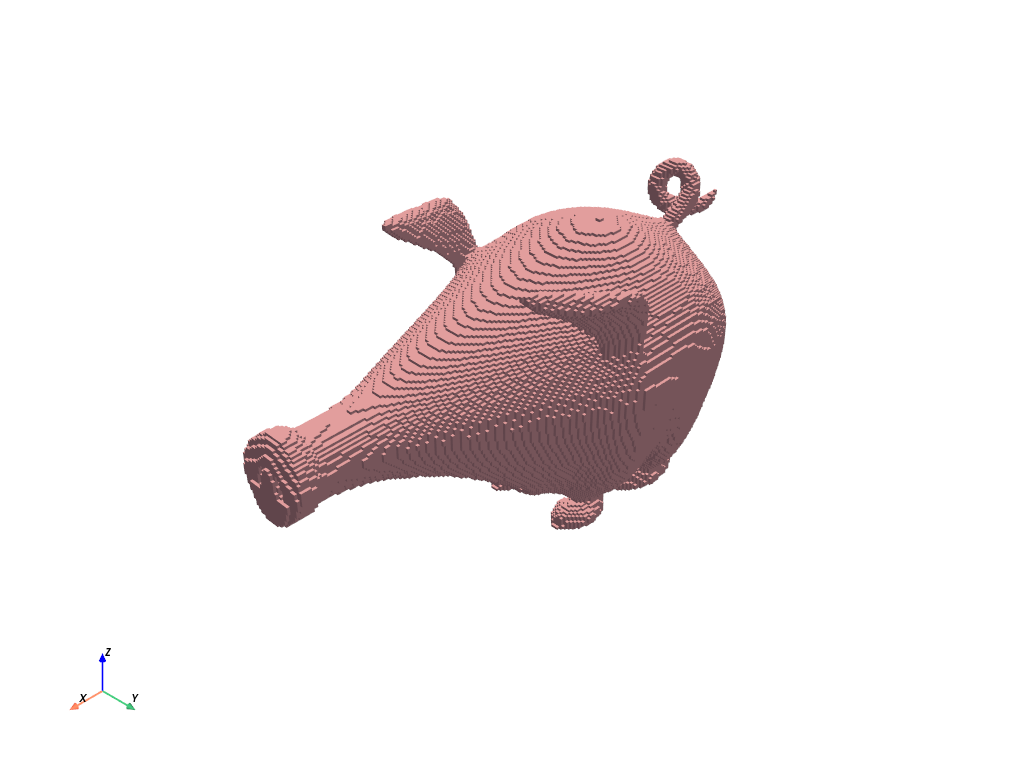

Mesh dimensions (x, y, z): (256, 256, 256)
Box size (nm): (np.float64(640.0), np.float64(640.0), np.float64(640.0))
Pig spans (nm): (np.float64(512.0), np.float64(223.23), np.float64(300.07))
Clearance to each -/+ face:
  x: 64.00 nm (25.6 cells)
  y: 208.39 nm (83.4 cells)
  z: 169.97 nm (68.0 cells)
Magnetic cells: 586,013
C:\Users\Artej\AppData\Local\Temp\ovftoolkit-imported-geometry-j73v4jkq\pig-geometry.ovf


In [2]:
# Editable mesh controls. An occupancy of 0.80 leaves 10% of the x length
# between the pig and each x face because the model is centered.
mesh_dimensions = np.asarray((256, 256, 256), dtype=int)
cell_nm = 2.5
primary_occupancy = 0.80

if mesh_dimensions.shape != (3,) or np.any(mesh_dimensions <= 0):
    raise ValueError("mesh_dimensions must contain three positive integers")
if not np.isfinite(cell_nm) or cell_nm <= 0:
    raise ValueError("cell_nm must be positive")
if not 0 < primary_occupancy <= 1:
    raise ValueError("primary_occupancy must be in the interval (0, 1]")

surface_model = pv.read(model_file)
if isinstance(surface_model, pv.MultiBlock):
    surface_model = surface_model.combine().extract_surface()
surface_model = surface_model.triangulate().clean()
if surface_model.n_open_edges:
    raise ValueError(f"Pig surface has {surface_model.n_open_edges} open edges")

# OBJ (x, y, z) -> simulation (length, width, vertical) = (z, x, y).
points = np.asarray(surface_model.points)[:, [2, 0, 1]]
points -= (points.min(axis=0) + points.max(axis=0)) / 2
box_size_nm = mesh_dimensions * cell_nm
pig_length_nm = primary_occupancy * box_size_nm[0]
points *= pig_length_nm / np.ptp(points[:, 0])
spans_nm = np.ptp(points, axis=0)
clearance_nm = (box_size_nm - spans_nm) / 2
if np.any(clearance_nm < 0):
    overflowing_axes = "xyz"[int(np.argmin(clearance_nm))]
    raise ValueError(
        f"The scaled pig does not fit along {overflowing_axes}; reduce "
        "primary_occupancy or enlarge that mesh dimension"
    )

target_center = box_size_nm / 2
surface_model.points = points
surface_model.translate(target_center, inplace=True)

reference = pv.ImageData(
    dimensions=tuple(int(value) for value in mesh_dimensions),
    spacing=(cell_nm, cell_nm, cell_nm),
    origin=(cell_nm / 2, cell_nm / 2, cell_nm / 2),
)
binary = surface_model.voxelize_binary_mask(reference_volume=reference)
fill = np.asarray(binary.point_data["mask"]).reshape(
    (mesh_dimensions[2], mesh_dimensions[1], mesh_dimensions[0]), order="C"
)
if not fill.any():
    raise RuntimeError("Voxelization produced an empty geometry")

geometry = ovf.VField()
geometry.data = fill[..., np.newaxis].astype(np.float32)
geometry.dummy_header((cell_nm * 1e-9,) * 3)
geometry.header["Title"] = "Voxelized Origins of the Pig geometry"
geometry.header["Desc"] = "CC0 pig body voxelized with PyVista"
geometry_file = work_dir / "pig-geometry.ovf"
with ovf.writer(geometry_file) as destination:
    destination.write(geometry)

preview = binary.points_to_cells().threshold(0.5)
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(preview, color="lightpink", show_edges=False)
plotter.add_axes()
plotter.view_isometric()
plotter.show()

print(f"Mesh dimensions (x, y, z): {tuple(map(int, mesh_dimensions))}")
print(f"Box size (nm): {tuple(box_size_nm)}")
print(f"Pig spans (nm): {tuple(np.round(spans_nm, 2))}")
print("Clearance to each -/+ face:")
for axis, distance_nm in zip("xyz", clearance_nm):
    print(f"  {axis}: {distance_nm:.2f} nm ({distance_nm / cell_nm:.1f} cells)")
print(f"Magnetic cells: {int(fill.sum()):,}")
print(geometry_file)

## Initialize the geometry directly from OVF and relax it

MuMax3's upstream `ext_InitGeomFromOVF` function sets the grid dimensions, cell sizes, and geometry from the scalar OVF header, so no duplicated mesh configuration is needed.


In [3]:
source_file = work_dir / "pig.mx3"
output_dir = work_dir / "pig.out"
text = template.read_text(encoding="utf-8")
if text.count("@GEOMETRY_FILE@") != 1:
    raise ValueError("Expected exactly one @GEOMETRY_FILE@ placeholder")
source_file.write_text(
    text.replace("@GEOMETRY_FILE@", geometry_file.resolve().as_posix()),
    encoding="utf-8",
)
subprocess.run([str(mumax3), "-o", str(output_dir), str(source_file)], check=True)

CompletedProcess(args=['C:\\Users\\Artej\\go\\bin\\mumax3.exe', '-o', 'C:\\Users\\Artej\\AppData\\Local\\Temp\\ovftoolkit-imported-geometry-j73v4jkq\\pig.out', 'C:\\Users\\Artej\\AppData\\Local\\Temp\\ovftoolkit-imported-geometry-j73v4jkq\\pig.mx3'], returncode=0)

## Map magnetization onto the pig surface

The voxel geometry is contoured at half fill. Magnetization is sampled onto that surface, decomposed into normal and tangential components, and converted to RGB using the mapping described above.


In [4]:
def load_single(path):
    with ovf.reader(path) as source:
        return source[0]

result_geometry = load_single(output_dir / "geometry.ovf")
magnetization = load_single(output_dir / "magnetization.ovf")
demag = load_single(output_dir / "B_demag.ovf")
x, y, z = result_geometry.meshgrid()

nz, ny, nx, _ = result_geometry.data.shape
visualization_grid = pv.ImageData(
    dimensions=(nx, ny, nz),
    spacing=(
        float(x[0, 0, 1] - x[0, 0, 0]) * 1e9,
        float(y[0, 1, 0] - y[0, 0, 0]) * 1e9,
        float(z[1, 0, 0] - z[0, 0, 0]) * 1e9,
    ),
    origin=(float(x[0, 0, 0]) * 1e9, float(y[0, 0, 0]) * 1e9, float(z[0, 0, 0]) * 1e9),
)
visualization_grid.point_data["geometry"] = result_geometry.data[..., 0].ravel(order="C")
visualization_grid.point_data["m"] = magnetization.data.reshape(-1, 3, order="C")
visualization_grid.point_data["B_demag"] = demag.data.reshape(-1, 3, order="C")
visualization_grid.point_data["B_magnitude"] = np.linalg.norm(demag.data, axis=-1).ravel(order="C")
visualization_grid.set_active_vectors("B_demag")

pig_surface = visualization_grid.contour([0.5], scalars="geometry")
pig_surface = pig_surface.sample(visualization_grid)
pig_surface = pig_surface.compute_normals(
    point_normals=True, cell_normals=False, auto_orient_normals=True,
    consistent_normals=True,
)

normals = np.asarray(pig_surface.point_data["Normals"])
m_surface = np.asarray(pig_surface.point_data["m"])
m_norm = np.linalg.norm(m_surface, axis=1, keepdims=True)
m_surface = np.divide(m_surface, m_norm, out=np.zeros_like(m_surface), where=m_norm > 0)
normal_component = np.clip(np.einsum("ij,ij->i", m_surface, normals), -1, 1)
tangent = m_surface - normal_component[:, None] * normals
tangent_magnitude = np.clip(np.linalg.norm(tangent, axis=1), 0, 1)

reference_axis = np.tile((0.0, 0.0, 1.0), (len(normals), 1))
reference_axis[np.abs(normals[:, 2]) > 0.9] = (0.0, 1.0, 0.0)
tangent_x = np.cross(reference_axis, normals)
tangent_x /= np.linalg.norm(tangent_x, axis=1, keepdims=True)
tangent_y = np.cross(normals, tangent_x)
angle = np.arctan2(
    np.einsum("ij,ij->i", tangent, tangent_y),
    np.einsum("ij,ij->i", tangent, tangent_x),
)

hsv = np.column_stack((
    (angle + np.pi) / (2 * np.pi),
    tangent_magnitude,
    (normal_component + 1) / 2,
))
pig_surface.point_data["magnetization_rgb"] = (
    colors.hsv_to_rgb(hsv) * 255
).astype(np.uint8)

## Seed a few three-dimensional demagnetizing-field lines

Seed points are selected near well-separated surface poles with large $|m\cdot n|$, then moved slightly outward. This produces a readable handful of field lines instead of filling the scene with a dense streamline forest.


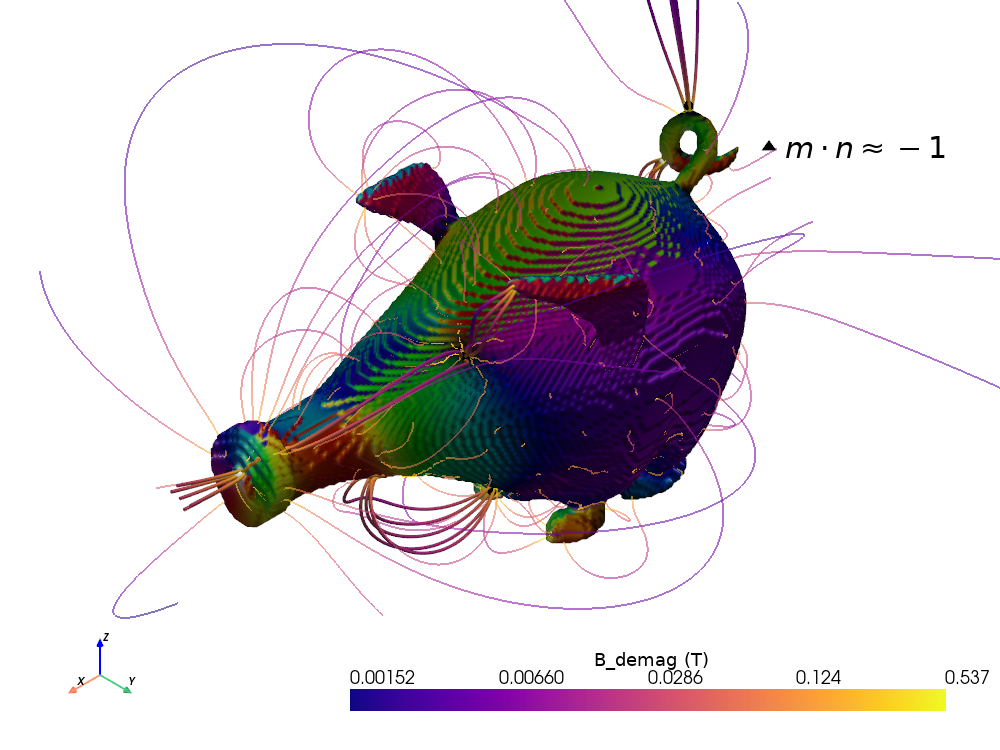

Seeded 200 sparse surface streamlines plus 5-line bundles at 3 positive and 3 negative pole centres


In [14]:
diagonal = float(pig_surface.length)
minimum_separation = 0.18 * diagonal

def separated_pole_indices(indices, count):
    selected_indices = []
    selected_points = []
    for index in indices:
        candidate = pig_surface.points[index]
        if all(np.linalg.norm(candidate - existing) >= minimum_separation for existing in selected_points):
            selected_indices.append(index)
            selected_points.append(candidate)
        if len(selected_indices) == count:
            break
    return selected_indices

# Choose balanced, well-separated pole centres close to m.n = +1 and -1.
positive_indices = separated_pole_indices(np.argsort(normal_component)[::-1], 3)
negative_indices = separated_pole_indices(np.argsort(normal_component), 3)

def bundled_seeds(indices):
    points = []
    radius = 1.25 * cell_nm
    offsets = ((0, 0), (1, 0), (-1, 0), (0, 1), (0, -1))
    for index in indices:
        centre = pig_surface.points[index] + 1.5 * cell_nm * normals[index]
        for offset_x, offset_y in offsets:
            points.append(
                centre
                + radius * offset_x * tangent_x[index]
                + radius * offset_y * tangent_y[index]
            )
    return points

def distributed_surface_indices(count):
    # Farthest-point sampling gives broad, deterministic surface coverage.
    candidate_indices = np.arange(0, pig_surface.n_points, max(1, pig_surface.n_points // 1500))
    candidate_points = np.asarray(pig_surface.points)[candidate_indices]
    centre = candidate_points.mean(axis=0)
    first = int(np.argmax(np.linalg.norm(candidate_points - centre, axis=1)))
    selected = [first]
    minimum_distance = np.linalg.norm(candidate_points - candidate_points[first], axis=1)
    for _ in range(1, count):
        next_index = int(np.argmax(minimum_distance))
        selected.append(next_index)
        minimum_distance = np.minimum(
            minimum_distance,
            np.linalg.norm(candidate_points - candidate_points[next_index], axis=1),
        )
    return candidate_indices[np.asarray(selected)]

positive_centres = pv.PolyData(
    np.asarray([pig_surface.points[i] + 1.5 * cell_nm * normals[i] for i in positive_indices])
)
negative_centres = pv.PolyData(
    np.asarray([pig_surface.points[i] + 1.5 * cell_nm * normals[i] for i in negative_indices])
)

pole_seed_points = bundled_seeds(positive_indices) + bundled_seeds(negative_indices)
pole_seeds = pv.PolyData(np.asarray(pole_seed_points))

background_indices = distributed_surface_indices(200)
background_seed_points = (
    np.asarray(pig_surface.points)[background_indices]
    + .5 * cell_nm * normals[background_indices]
)
background_seeds = pv.PolyData(background_seed_points)

streamline_options = dict(
    vectors="B_demag",
    integration_direction="both",
    initial_step_length=0.3,
    max_step_length=0.75,
    max_steps=2500,
    max_length=4 * diagonal,
    terminal_speed=max(float(visualization_grid["B_magnitude"].max()) * 1e-7, 1e-12),
    compute_vorticity=False,
)
background_streamlines = visualization_grid.streamlines_from_source(
    background_seeds, **streamline_options,
)
pole_streamlines = visualization_grid.streamlines_from_source(
    pole_seeds, **streamline_options,
)

plotter = pv.Plotter(notebook=True, window_size=(1000, 750))
plotter.set_background("white")
plotter.add_mesh(
    pig_surface, scalars="magnetization_rgb", rgb=True,
    smooth_shading=True, show_scalar_bar=False,
)
if background_streamlines.n_points:
    plotter.add_mesh(
        background_streamlines,
        scalars="B_magnitude", cmap="plasma", log_scale=True,
        line_width=2, opacity=0.55, show_scalar_bar=False,
    )
if pole_streamlines.n_points:
    plotter.add_mesh(
        pole_streamlines.tube(radius=.5 * cell_nm),
        scalars="B_magnitude", cmap="plasma", log_scale=True,
        scalar_bar_args={"title": "|B_demag| (T)"},
    )
plotter.add_mesh(
    positive_centres, color="white", point_size=10,
    render_points_as_spheres=True, label=r"$m\cdot n \approx +1$",
)
plotter.add_mesh(
    negative_centres, color="black", point_size=10,
    render_points_as_spheres=True, label=r"$m\cdot n \approx -1$",
)
plotter.add_legend()
plotter.add_axes()
plotter.view_isometric()
plotter.camera.zoom(2)
plotter.show()

print(
    f"Seeded {len(background_indices)} sparse surface streamlines plus "
    f"5-line bundles at {len(positive_indices)} positive and "
    f"{len(negative_indices)} negative pole centres"
)

## Read the surface-color legend

The horizontal coordinate is tangential direction in the local surface basis. The vertical coordinate is the normal projection; it controls brightness exactly as used on the pig.


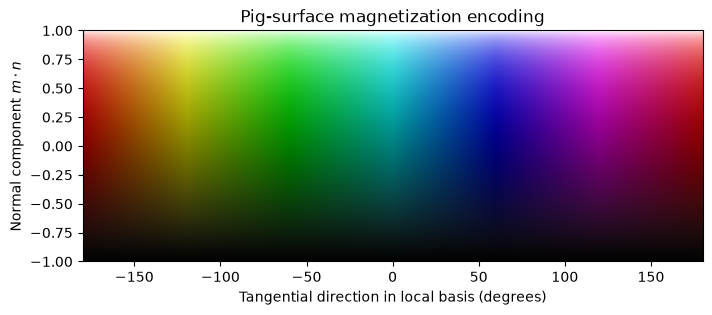

In [6]:
legend_angle = np.linspace(-np.pi, np.pi, 512)
legend_normal = np.linspace(-1, 1, 256)
legend_hue = (legend_angle[None, :] + np.pi) / (2 * np.pi)
legend_value = (legend_normal[:, None] + 1) / 2
legend_saturation = np.sqrt(np.maximum(0, 1 - legend_normal[:, None] ** 2))
legend_hsv = np.stack(np.broadcast_arrays(legend_hue, legend_saturation, legend_value), axis=-1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.imshow(
    colors.hsv_to_rgb(legend_hsv), origin="lower", aspect="auto",
    extent=(-180, 180, -1, 1),
)
ax.set(
    xlabel="Tangential direction in local basis (degrees)",
    ylabel=r"Normal component $m\cdot n$",
    title="Pig-surface magnetization encoding",
)
plt.show()

## Clean up

Run this only after retaining any generated files you want.


In [7]:
shutil.rmtree(work_dir)
print(f"Removed temporary workspace: {work_dir}")

Removed temporary workspace: C:\Users\Artej\AppData\Local\Temp\ovftoolkit-imported-geometry-zdrmngl5
